# Prepare

Run `generate_grid_graph_json.py` on whatever configuration you please

# Sampling
Run Julia code to sample partitions, e.g.
```
./sampling/run.sh --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1
```
On a Windows machine through Powershell, something like the following might work:
```
julia --project="sampling/runCycleWalkEnv" sampling/run_cyclewalk.jl --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1 --rng-seed 42
```

# Analysis

In [87]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data import generate_grid_shape, generate_shape_from_json
from hierachical import HClusters
from sample import SampleProcessor
from utils import (
    plot_district,
    plot_plan,
    plot_words_centroids,
    plot_words_list,
    plot_district_by_uid,
)
from word import PlanWordBuilder, WordStat
from scipy.cluster.hierarchy import dendrogram, linkage
from voronoi_gdf import gdf_from_graph_json
import time

square_side = 6
num_districts = 2

PRECINCT_FN = "data/graph/regular_hex_graph_6x6x6_2.json"
SAMPLE_FN = "local/output/reghex6x6x6-2/atlas.jsonl.gz"
OUT_DIR = "local/output/reghex6x6x6-2/processed"
# gdf = generate_grid_shape(square_side)
# gdf = generate_shape_from_json(PRECINCT_FN)

start_time = time.time()
gdf = gdf_from_graph_json(PRECINCT_FN, buffer_factor=0.01)
end_time = time.time()

print(f'gdf generation time: {end_time - start_time} seconds')

is_huge = True if square_side > 4 else False

gdf generation time: 0.053826093673706055 seconds


In [88]:
print(gdf.iloc[0])

node_name                                                     (-5,0)
precinct_id_str                                               (-5,0)
id                                                                 0
border_length                                                      3
x_location                                                      -5.0
y_location                                                       0.0
area                                                               1
population                                                         1
geometry           POLYGON ((-4.5 0.2886751345948129, -4.5 -0.288...
Name: 0, dtype: object


In [89]:
sp = SampleProcessor(PRECINCT_FN, OUT_DIR)
# run this once to process samples and dump artifacts for future use
sp.clean()
sp.process_samples([SAMPLE_FN], max_length=1000, min_step=100)
sp.load_processed()

Reading local\output\reghex6x6x6-2\atlas.jsonl.gz


plans: 100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 9965.65it/s]


We give each district a unique `district_uid'. Districts are stored via the precincts that they contain (i.e. as an array of ints).

In [90]:
sp.df_districts.head()

,district_str,district_uid
0,0.1.2.3.4.5.6.7.8.10.11.12.13.14.15.16.19.20.2...,0
1,0.1.2.3.4.5.6.7.8.10.11.12.13.14.15.18.21.22.2...,1
2,0.1.2.3.4.5.6.7.8.10.11.12.13.14.19.20.21.22.2...,2
3,0.1.2.3.4.5.6.7.8.10.11.12.19.20.28.29.37.38.3...,3
4,0.1.2.3.4.5.6.7.8.10.11.13.14.15.16.21.22.23.2...,4


Each plan is stored using `district_uid's and is given a 'plan_id'

In [91]:
sp.df_plans.head()

,step,plan_id,sample_tag,plan,plan_str
0,1000,0,atlas,"[627, 1955]",627.1955
1,2000,1,atlas,"[1866, 714]",714.1866
2,3000,2,atlas,"[1471, 264]",264.1471
3,4000,3,atlas,"[1632, 821]",821.1632
4,5000,4,atlas,"[1765, 54]",54.1765


We visualize the first sampled plan and its first district

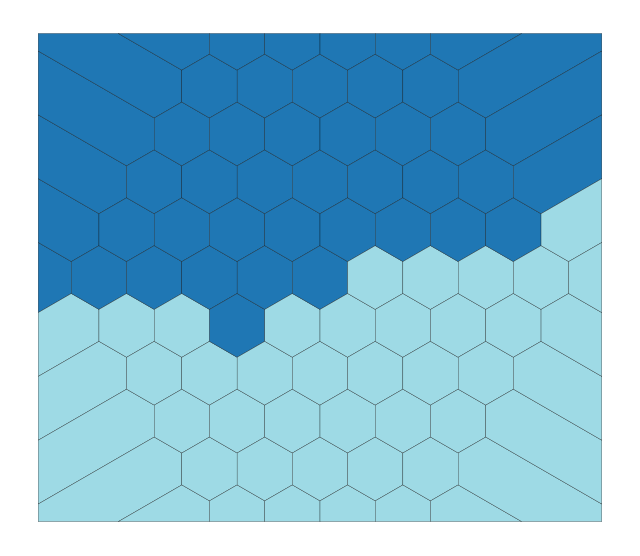

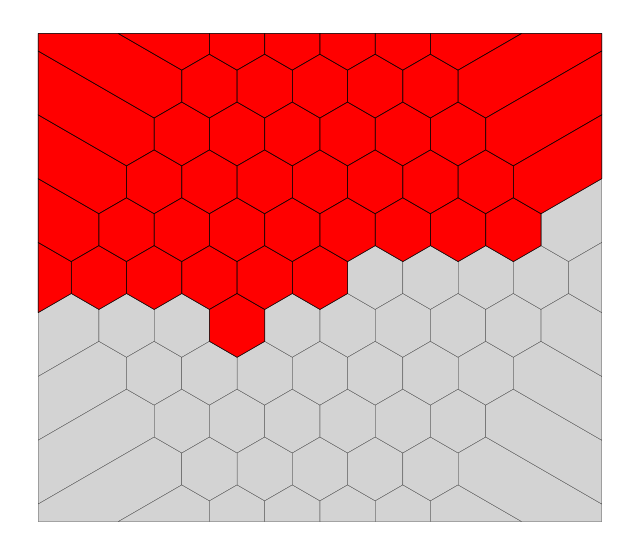

In [92]:
plan = sp.df_plans.iloc[0].plan
labels = sp.decode_plan_vector(plan)
plot_plan(gdf, labels)
plt.show()

district = sp.decode_district(plan[0])
plot_district(gdf, district)
plt.show()

Next, we run hcc and infer clusters at a given number of letters.

In [93]:
sp.load_distance_matrix()
sp.ensure_linkage()

num_letters = num_districts * 3
hc = HClusters(sp)
hc.update_clusters(num_letters)
hc.kcentroids()

  4%|███▋                                                                                         | 2/50 [00:00<00:05,  8.26it/s]

epoch 0: rel_improvement = 0.06221014492753623
epoch 1: rel_improvement = 0.02804929876753081


  8%|███████▍                                                                                     | 4/50 [00:00<00:06,  7.23it/s]

epoch 2: rel_improvement = 0.02583773899908574
epoch 3: rel_improvement = 0.03692822458889297


 10%|█████████▎                                                                                   | 5/50 [00:00<00:07,  6.08it/s]

epoch 4: rel_improvement = 0.028345055503770866


We visualize some letters 

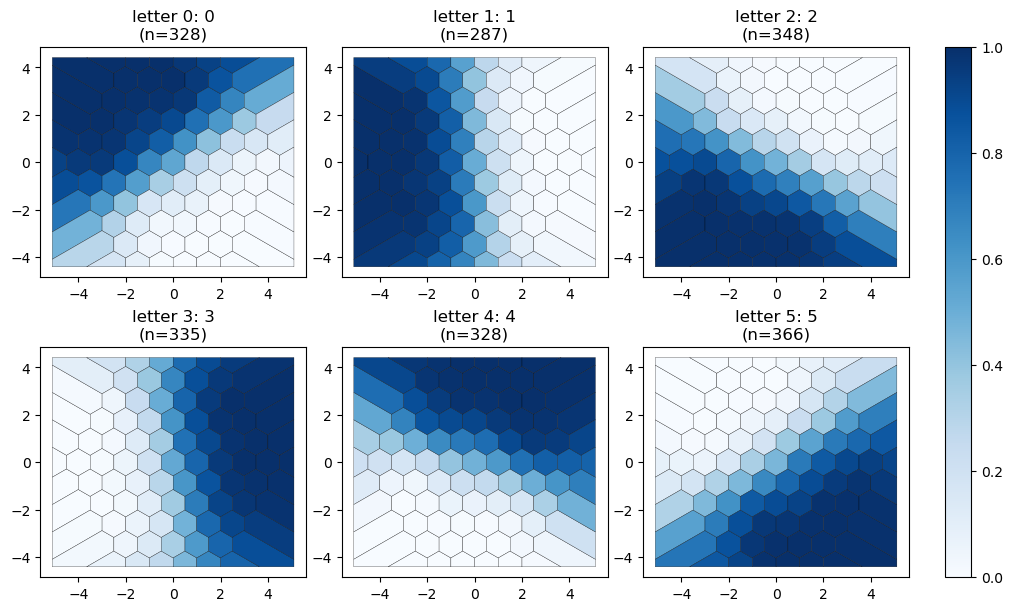

In [94]:
cluster_sizes = np.array([len(hc.c2i[i]) for i in range(num_letters)])

letters = list(range(num_letters))
plot_words_list(gdf, hc.cluster_densities, letters, cluster_sizes=cluster_sizes, cols=3, figsize=(10, 6))
plt.show()

We then use the letters to construct words via beam search with a prescribed `word_degree'

In [95]:
pw = PlanWordBuilder(sp, hc, word_degree=10, verbose=True, centroid_norm="l1").build()
pw.df_words.head()

Enumerating words: 100%|████████████████████████████████████████████████████████████████████| 996/996 [00:00<00:00, 11722.77it/s]


,plan_uid,plan,word,distance,min_distance,plan_str,word_str,word_uid
0,0,"[0, 1991]","[2, 3]",32.0,32.0,0.1991,2.3,9
1,0,"[0, 1991]","[2, 4]",34.0,32.0,0.1991,2.4,10
2,0,"[0, 1991]","[1, 3]",37.0,32.0,0.1991,1.3,6
3,0,"[0, 1991]","[1, 4]",39.0,32.0,0.1991,1.4,7
4,0,"[0, 1991]","[0, 2]",58.0,32.0,0.1991,0.2,1


We compute stationary distribution under some POU (controlled by temperature).

In [96]:
ws = WordStat(pw, temp=0.0, verbose=False)
df_top = ws.stationary_table().head(3).reset_index(drop=True)
df_top

,word_uid,word_str,word,stationary
0,10,2.4,"[2, 4]",0.0748
1,4,0.5,"[0, 5]",0.0737
2,14,4.5,"[4, 5]",0.0733


This is the flux matrix

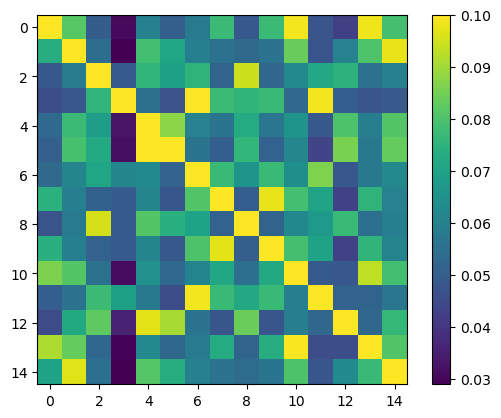

In [97]:
plt.imshow(ws.flux_matrix())
plt.colorbar()

These are some most frequent words under the stationary distribution

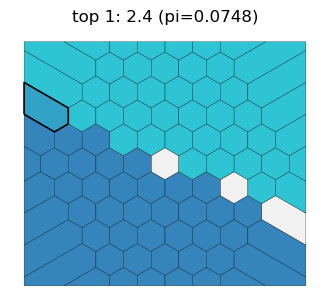

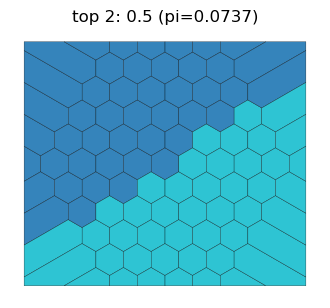

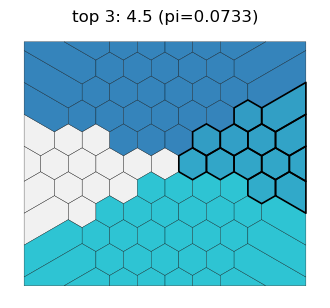

In [98]:
for i, row in df_top.iterrows():
    fig, ax = plot_words_centroids(
        gdf, hc.cluster_densities, row.word, ltr=True, figsize=(4, 4)
    )
    ax.set_title(f"top {i + 1}: {row.word_str} (pi={row.stationary:.3g})")
    plt.show()

Visualize dendrogram from sp linkage

In [99]:
def plot_dendrogram_from_linkage(Z, no_labels=False):
    fig, ax = plt.subplots(figsize=(12, 6))
    dendrogram(Z, ax=ax, no_labels=no_labels)
    ax.set_xlabel("District UID")
    ax.set_ylabel("Merge distance")
    ax.set_title("District clustering dendrogram")
    plt.tight_layout()
    plt.show()
if not is_huge:
    plot_dendrogram_from_linkage(np.load(sp.paths.linkage).astype(np.float64))

In [100]:
# Code by Claude Sonnet 4.6

Z = np.load(sp.paths.linkage).astype(np.float64)
n = int(Z.shape[0] + 1)

from collections import defaultdict

node_to_cluster = {}  # leaf -> cluster id
cluster_members = defaultdict(set)
cluster_first_dist = {}  # cluster id -> distance at which it was first formed
cluster_counter = 0

for i, (a, b, dist, size) in enumerate(Z):
    a, b = int(a), int(b)
    new_node = n + i

    a_leaves = cluster_members[a] if a >= n else {a}
    b_leaves = cluster_members[b] if b >= n else {b}
    cluster_members[new_node] = a_leaves | b_leaves

    a_assigned_leaves = {leaf for leaf in a_leaves if leaf in node_to_cluster}
    b_assigned_leaves = {leaf for leaf in b_leaves if leaf in node_to_cluster}
    a_assigned = len(a_assigned_leaves) > 0
    b_assigned = len(b_assigned_leaves) > 0

    if not a_assigned and not b_assigned:
        cid = cluster_counter
        cluster_counter += 1
        cluster_first_dist[cid] = dist
        for leaf in a_leaves | b_leaves:
            node_to_cluster[leaf] = cid
    elif a_assigned and not b_assigned:
        cid = node_to_cluster[next(iter(a_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid
    elif b_assigned and not a_assigned:
        cid = node_to_cluster[next(iter(b_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid

# Collect clusters
lowest_level = defaultdict(set)
for leaf, cid in node_to_cluster.items():
    lowest_level[cid].add(leaf)

singletons = [{i} for i in range(n) if i not in node_to_cluster]
all_lowest_clusters = list(lowest_level.values()) + singletons

print(f"{len(all_lowest_clusters)} total lowest-level clusters ({len(singletons)} singletons)")
for c in sorted(all_lowest_clusters, key=len, reverse=True):
    print(sorted(c))

1202 total lowest-level clusters (428 singletons)
[278, 284, 344]
[227, 392, 396]
[516, 520, 541]
[684, 735, 736]
[1130, 1151, 1155]
[1391, 1451, 1457]
[1844, 1845, 1913]
[1698, 1874, 1875]
[415, 439, 440]
[454, 596, 597]
[751, 842, 843]
[1074, 1075, 1217]
[1165, 1166, 1173]
[1604, 1605, 1829]
[1207, 1237, 1475]
[952, 1938, 1981]
[11, 12]
[135, 136]
[143, 144]
[161, 162]
[176, 178]
[307, 308]
[279, 345]
[388, 389]
[419, 420]
[511, 529]
[475, 534]
[572, 574]
[588, 600]
[686, 688]
[765, 766]
[797, 799]
[802, 803]
[821, 822]
[813, 824]
[819, 826]
[900, 910]
[913, 914]
[908, 986]
[1070, 1071]
[1097, 1099]
[1142, 1160]
[1137, 1196]
[1251, 1252]
[1310, 1311]
[1057, 1316]
[1314, 1324]
[1346, 1347]
[1427, 1428]
[1390, 1456]
[1557, 1559]
[1573, 1574]
[1631, 1632]
[1627, 1634]
[1629, 1640]
[1650, 1651]
[1654, 1655]
[1675, 1676]
[1683, 1684]
[1814, 1815]
[1751, 1886]
[1909, 1910]
[9, 10]
[16, 22]
[29, 37]
[33, 44]
[53, 55]
[66, 67]
[56, 83]
[23, 121]
[124, 125]
[134, 137]
[108, 140]
[110, 145]
[1

In [101]:
if not is_huge:
    all_lowest_clusters = [sorted(c) for c in all_lowest_clusters]
    largest_LL_cluster_size = max([len(c) for c in all_lowest_clusters])
    n_LL_clusters = len(all_lowest_clusters)
    
    fig, axes = plt.subplots(n_LL_clusters, largest_LL_cluster_size)
    
    for i in range(n_LL_clusters):
        for j in range(len(all_lowest_clusters[i])):
            plot_district_by_uid(gdf, sp.df_districts, all_lowest_clusters[i][j], ax=axes[i][j])
            axes[i][j].text(
                -0.05, 0.5, str(all_lowest_clusters[i][j]),
                transform=axes[i][j].transAxes,
                fontsize=7, va="center", ha="right"
            )
        for j in range(len(all_lowest_clusters[i]), largest_LL_cluster_size):
            plot_district(gdf, np.zeros(len(gdf), dtype=bool), ax=axes[i][j])
    plt.tight_layout()
    plt.show()